<a href="https://colab.research.google.com/github/Mru321/CSI-Cross-Environment-Generalization/blob/main/CNN%20%2B%20Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    ReLU,
    Dropout,
    Dense,
    GlobalAveragePooling1D,
    LayerNormalization,
    MultiHeadAttention,
    Add
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

RAW_DIR = "/content/drive/MyDrive/Project/Project1/raw_data/renew_dataset/tvt_open_source/raw_traces"
PROCESSED_DIR = "/content/drive/MyDrive/Project/Project1/processed"

In [ ]:
import os
import numpy as np

files = sorted([f for f in os.listdir(PROCESSED_DIR) if f.endswith(".npy")])

file_info = []

for f in files:
    path = os.path.join(PROCESSED_DIR, f)

    label = 0 if "NLOS" in f else 1

    # FIXED env extraction
    env = f.replace(".npy", "")

    file_info.append((path, label, env))

In [ ]:
train_envs = [
    "channe14_LOS_cluster1",
    "channe14_LOS_cluster2",
    "channe14_NLOS_cluster1",
    "channe14_NLOS_cluster2",
    "channe14_NLOS_cluster3"
]

test_envs = [
    "channe14_LOS_cluster3",
    "channe14_LOS_cluster4",
    "channe14_NLOS_cluster4",
    "channe14_NLOS_cluster5"
]

In [ ]:
path="/content/drive/MyDrive/Project/Project1/processed/channe14_LOS_cluster1.npy"
sample = np.load(path)

print(sample.mean())
print(sample.std())
print(sample.min())
print(sample.max())

3.2117188e-07
1.0000001
-4.267014
8.4409685


In [ ]:
X_train_list = []
y_train_list = []

X_test_list = []
y_test_list = []

for path, label, env in file_info:

    data = np.load(path)

    # TRAIN
    if env in train_envs:

        X_train_list.append(data)

        y_train_list.append(
            np.full((data.shape[0],), label)
        )

    # TEST
    elif env in test_envs:

        X_test_list.append(data)

        y_test_list.append(
            np.full((data.shape[0],), label)
        )

In [ ]:
X_train = np.vstack(X_train_list)
y_train = np.hstack(y_train_list)

X_test = np.vstack(X_test_list)
y_test = np.hstack(y_test_list)

In [ ]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(30492, 72)
(30492,)
(24333, 72)
(24333,)


In [ ]:
X_train = X_train.reshape(X_train.shape[0], 72, 1)
X_test = X_test.reshape(X_test.shape[0], 72, 1)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(30492, 72, 1)
(24333, 72, 1)


In [ ]:
print(np.isnan(X_train).sum())
print(np.isinf(X_train).sum())

0
0


In [ ]:
def transformer_encoder(
    inputs,
    head_size,
    num_heads,
    ff_dim,
    dropout=0.2
):

    # =========================================
    # MULTI HEAD SELF ATTENTION
    # =========================================

    attention = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    attention = Dropout(dropout)(attention)

    attention = LayerNormalization(
        epsilon=1e-6
    )(attention)

    # Residual connection
    x = Add()([inputs, attention])

    # =========================================
    # FEED FORWARD NETWORK
    # =========================================

    ff = Dense(
        ff_dim,
        activation="relu"
    )(x)

    ff = Dropout(dropout)(ff)

    ff = Dense(
        inputs.shape[-1]
    )(ff)

    ff = LayerNormalization(
        epsilon=1e-6
    )(ff)

    # Residual connection
    output = Add()([x, ff])

    return output

In [ ]:
def build_cnn_transformer():

    # =========================================
    # INPUT
    # =========================================

    inputs = Input(shape=(72,1))

    # =========================================
    # CNN FEATURE EXTRACTION
    # =========================================

    x = Conv1D(
        filters=64,
        kernel_size=3,
        padding='same'
    )(inputs)

    x = BatchNormalization()(x)

    x = ReLU()(x)

    # -----------------------------------------

    x = Conv1D(
        filters=128,
        kernel_size=3,
        padding='same'
    )(x)

    x = BatchNormalization()(x)

    x = ReLU()(x)

    x = Dropout(0.2)(x)


    # =========================================
    # TRANSFORMER BLOCK 1
    # =========================================

    x = transformer_encoder(
        x,
        head_size=32,
        num_heads=2,
        ff_dim=64,
        dropout=0.1
    )


    # =========================================
    # GLOBAL AVERAGE POOLING
    # =========================================

    x = GlobalAveragePooling1D()(x)

    # =========================================
    # DENSE CLASSIFICATION HEAD
    # =========================================

    x = Dense(
        128,
        activation='relu'
    )(x)

    x = Dropout(0.3)(x)

    x = Dense(
        64,
        activation='relu'
    )(x)

    x = Dropout(0.3)(x)

    # =========================================
    # OUTPUT LAYER
    # =========================================

    outputs = Dense(
        1,
        activation='sigmoid'
    )(x)

    # =========================================
    # CREATE MODEL
    # =========================================

    model = Model(inputs, outputs)

    return model

In [ ]:
model = build_cnn_transformer()

In [ ]:
model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 72, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 72, 64)    │        256 │ input_layer_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 64)    │        256 │ conv1d_25[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_25 (ReLU)     │ (None, 72, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 72, 128)   │     24,704 │ re_lu_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 128)   │        512 │ conv1d_26[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_26 (ReLU)     │ (None, 72, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_82          │ (None, 72, 128)   │          0 │ re_lu_26[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 72, 128)   │     33,088 │ dropout_82[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_82[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_84          │ (None, 72, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 72, 128)   │        256 │ dropout_84[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_30 (Add)        │ (None, 72, 128)   │          0 │ dropout_82[0][0], │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_66 (Dense)    │ (None, 72, 64)    │      8,256 │ add_30[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_85          │ (None, 72, 64)    │          0 │ dense_66[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_67 (Dense)    │ (None, 72, 128)   │      8,320 │ dropout_85[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 72, 128)   │        256 │ dense_67[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_31 (Add)        │ (None, 72, 128)   │          0 │ add_30[0][0],     │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ add_31[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_68 (Dense)    │ (None, 128)       │     16,512 │ global_average_p

 Total params: 100,737 (393.50 KB)

 Trainable params: 100,353 (392.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.00003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, class_weights)
)

print(class_weights)

{np.int64(0): np.float64(1.0741915028535194), np.int64(1): np.float64(0.9353948094975152)}


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=20,

    batch_size=128,

    shuffle=True,

    callbacks=[early_stop, reduce_lr],

    class_weight=class_weights,

    verbose=1
)

Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 104s 408ms/step - accuracy: 0.8129 - loss: 0.4016 - val_accuracy: 0.6784 - val_loss: 1.1042 - learning_rate: 3.0000e-05
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 105s 438ms/step - accuracy: 0.9678 - loss: 0.1028 - val_accuracy: 0.6441 - val_loss: 1.3461 - learning_rate: 3.0000e-05
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 138s 422ms/step - accuracy: 0.9848 - loss: 0.0472 - val_accuracy: 0.6553 - val_loss: 2.5399 - learning_rate: 3.0000e-05
Epoch 4/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.9923 - loss: 0.0268
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-05.
239/239 ━━━━━━━━━━━━━━━━━━━━ 96s 402ms/step - accuracy: 0.9923 - loss: 0.0251 - val_accuracy: 0.6570 - val_loss: 2.9608 - learning_rate: 3.0000e-05
Epoch 5/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 98s 412ms/step - accuracy: 0.9942 - loss: 0.0179 - val_accuracy: 0.6578 - val_loss: 2.9768 - learning_rate: 1.5000e-05
Epoch 6/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 101s 422

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

761/761 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.6784 - loss: 1.1042
Test Loss : 1.104215145111084
Test Accuracy : 0.6784202456474304


In [ ]:
predictions = model.predict(X_test)

predicted_labels = (
    predictions > 0.5
).astype(int)

761/761 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step


In [ ]:
acc = accuracy_score(
    y_test,
    predicted_labels
)

print("Final Accuracy :", acc)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        predicted_labels
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predicted_labels
    )
)

Final Accuracy : 0.813011137138865

Confusion Matrix:
[[ 7039  1081]
 [ 3469 12744]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.87      0.76      8120
           1       0.92      0.79      0.85     16213

    accuracy                           0.81     24333
   macro avg       0.80      0.83      0.80     24333
weighted avg       0.84      0.81      0.82     24333



In [ ]:
print("AUC Score :", roc_auc)

AUC Score : 0.9639307605737536


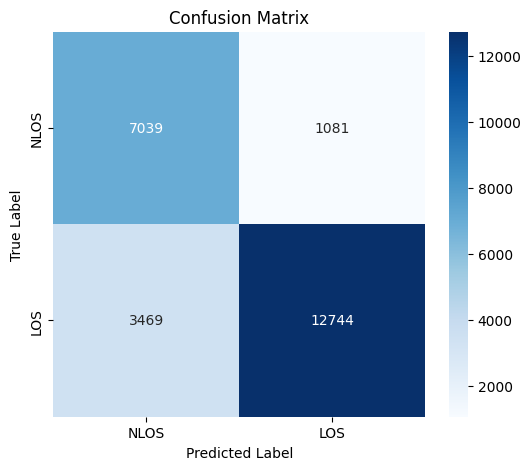

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    predicted_labels
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NLOS','LOS'],
    yticklabels=['NLOS','LOS']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

761/761 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step


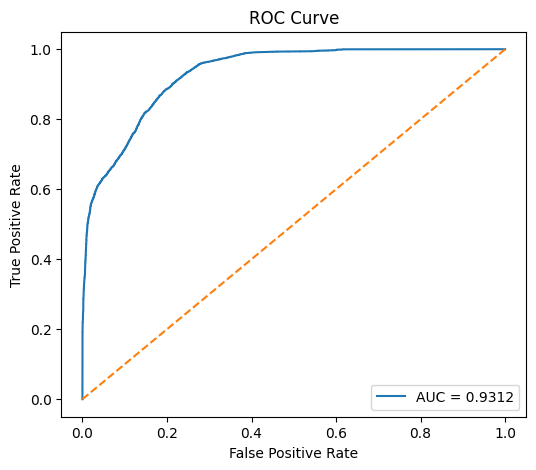

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

# Probability predictions
y_prob = model.predict(X_test)

# ROC
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
model.save("best_cnn_transformer_model.h5")

In [ ]:
model.save("best_cnn_transformer_model.keras")

In [ ]:
from google.colab import files

files.download(
    "best_cnn_transformer_model.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("TRAIN DATA")

print("LOS samples  :", np.sum(y_train == 1))
print("NLOS samples :", np.sum(y_train == 0))

TRAIN DATA
LOS samples  : 16299
NLOS samples : 14193


In [ ]:
print("\nTEST DATA")

print("LOS samples  :", np.sum(y_test == 1))
print("NLOS samples :", np.sum(y_test == 0))


TEST DATA
LOS samples  : 16213
NLOS samples : 8120
